<a href="https://colab.research.google.com/github/harshithasmj/Stress-Testing-Organizational-Stability/blob/main/StressTestingOrgStability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [193]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [194]:
# ======================
# CONFIGURATION
# ======================

company = {
    "employees": 500,
    "avg_salary": 85000,
    "annual_revenue": 120_000_000,
    "operating_margin": 0.18,
    "leadership_positions": 20
}

scenarios = {
    "Base": {"attrition": 0.12, "leadership": 0.08, "revenue_shock": 0.02},
    "Moderate Stress": {"attrition": 0.18, "leadership": 0.12, "revenue_shock": -0.05},
    "Severe Stress": {"attrition": 0.25, "leadership": 0.18, "revenue_shock": -0.12}
}

In [195]:
def evaluate_scenario(company, scenario):

    employees_lost = company["employees"] * scenario["attrition"]
    replacement_cost = employees_lost * company["avg_salary"] * 0.5

    leadership_loss = company["leadership_positions"] * scenario["leadership"]
    leadership_cost = leadership_loss * 200000

    revenue_change = company["annual_revenue"] * scenario["revenue_shock"]

    total_risk = replacement_cost + leadership_cost - revenue_change

    return total_risk

In [196]:
  results = {}

for name, scenario in scenarios.items():
    results[name] = evaluate_scenario(company, scenario)

results

{'Base': 470000.0, 'Moderate Stress': 10305000.0, 'Severe Stress': 20432500.0}

In [197]:
max_risk = max(results.values())
min_risk = min(results.values())

def stability_from_revenue(risk, company):
    risk_ratio = risk / company["annual_revenue"]

    if risk_ratio < 0.01:
        return 90
    elif risk_ratio < 0.02:
        return 70
    elif risk_ratio < 0.03:
        return 50
    elif risk_ratio < 0.04:
        return 40
    elif risk_ratio < 0.05:
        return 30
    elif risk_ratio < 0.06:
        return 25
    elif risk_ratio < 0.10: # New threshold for Moderate Stress
        return 20
    elif risk_ratio < 0.15: # New threshold for higher risk
        return 10
    else: # For very high risk, like Severe Stress
        return 5

stability_scores = {}

for name, risk in results.items():
    stability_scores[name] = stability_from_revenue(risk, company)

stability_scores

{'Base': 90, 'Moderate Stress': 20, 'Severe Stress': 5}

In [198]:
for name, risk in results.items():
    percent = (risk / company["annual_revenue"]) * 100
    print(f"{name}: {percent:.2f}% of annual revenue exposed.")

Base: 0.39% of annual revenue exposed.
Moderate Stress: 8.59% of annual revenue exposed.
Severe Stress: 17.03% of annual revenue exposed.


In [199]:
def decision_recommendation(score):
    if score >= 70:
        return "Stable – Maintain strategy"
    elif score >= 40:
        return "Caution – Implement retention & leadership support"
    else:
        return "Critical – Immediate structural intervention required"

recommendations = {k: decision_recommendation(v) for k, v in stability_scores.items()}
recommendations

{'Base': 'Stable – Maintain strategy',
 'Moderate Stress': 'Critical – Immediate structural intervention required',
 'Severe Stress': 'Critical – Immediate structural intervention required'}

In [200]:
improved_scenario = scenarios["Severe Stress"].copy()
improved_scenario["attrition"] = 0.18  # simulate retention investment

improved_risk = evaluate_scenario(company, improved_scenario)

improved_score = 100 - ((improved_risk - min_risk) / (max_risk - min_risk)) * 100
round(improved_score, 2)

7.45

In [201]:
summary = pd.DataFrame({
    "Risk Exposure ($)": results,
    "Stability Score": stability_scores,
    "Recommendation": recommendations
})

summary

,Risk Exposure ($),Stability Score,Recommendation
Base,470000.0,90,Stable – Maintain strategy
Moderate Stress,10305000.0,20,Critical – Immediate structural intervention r...
Severe Stress,20432500.0,5,Critical – Immediate structural intervention r...


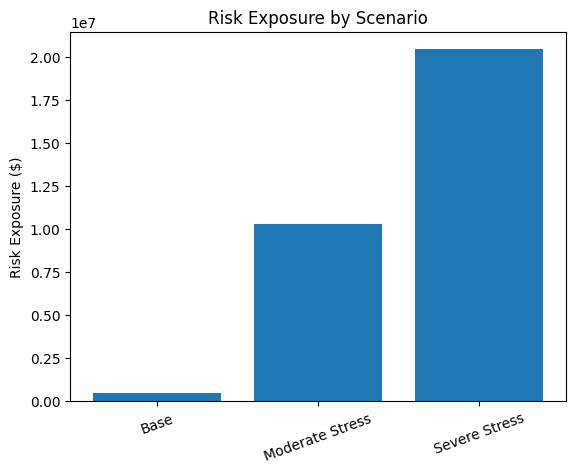

In [202]:
import matplotlib.pyplot as plt

plt.bar(results.keys(), results.values())
plt.title("Risk Exposure by Scenario")
plt.ylabel("Risk Exposure ($)")
plt.xticks(rotation=20)
plt.show()